# Insper - Modelagem e Simulação do Mundo Físico

## Atividade - ODEINT

----

### Item 1 - Resolvendo uma equação diferencial utilizando a função `odeint` do Python

Na aula passada, você utilizou o método de Euler para resolver um modelo dado pela seguinte equação diferencial: 

$$\dfrac{dy(t)}{dt}=y(t)$$
$$y(0) = 1$$

Agora, vamos resolvê-lo utilizando a função `odeint` do Python.



#### a) Modelo

Implemente uma função denominada ```modelo``` que receba a variável $y(t)$ e o instante de tempo $t$ e retorne a taxa de variação $\frac{dy(t)}{dt}$. Mesmo que sua função não utilize a variável $t$, ela é obrigatória para o correto funcionamento da função ```odeint```.

In [1]:
# SEU CÓDIGO DO ITEM 1A
def modelo(y, t):
    dydt = y
    return dydt


#### b) Resolução numérica

Agora que você implementou a função ```modelo```, calcule uma lista de valores $[y(0) \quad y(t_1) \quad \cdots \quad y(t_n)]$ utilizando a função ```odeint```. Para isso, você vai precisar de:

- Uma condição inicial $y(0) = 1$
- Uma lista de tempo $[0 \quad t_1 \quad \cdots \quad t_n]$ com $\Delta t$ bem pequeno (use $\Delta t=10^{-3}s$ em uma lista de tempo de $0$ a $3$s.)

In [2]:
# SEU CÓDIGO DO ITEM 1B
from scipy.integrate import odeint
import numpy as np

y_0 = 1
dt = 1e-3
t_lista = np.arange(0,3,dt)

y = odeint(modelo, y_0, t_lista)

#### c) Gráfico

Por fim, plote um gráfico de $y(t)$ por $t$.

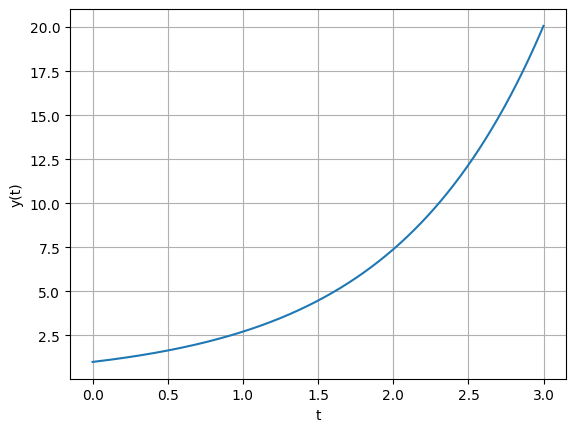

In [3]:
# SEU CÓDIGO DO ITEM 1C

import matplotlib.pyplot as plt


plt.plot(t_lista, y)

# Configura gráfico
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

----

### Item 2 - Outro exemplo

Resolva a equação diferencial a seguir usando `odeint`:

$$\dfrac{dA}{dt}=-2A+t^2$$
$$A(0) = 2$$

Considere uma lista de $0$ a $4 \,s$ com $\Delta t = 0,01$.

Após resolvê-la, plote o gráfico de $A(t)$ por $t$.



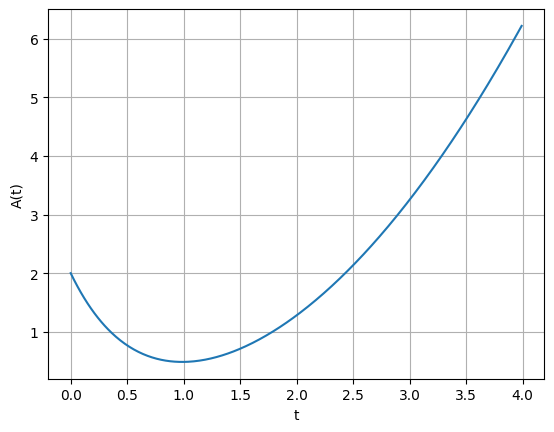

In [4]:
# SEU CÓDIGO DO ITEM 2

def modelo2(A, t):
    dAdt = - 2*A + t**2
    return dAdt

A_0 = 2
dt = 1e-2
lista_t = np.arange(0,4,dt)

lista_A = odeint(modelo2, A_0, lista_t)

plt.plot(lista_t, lista_A)

# Configura gráfico
plt.xlabel("t")
plt.ylabel("A(t)")
plt.grid(True)
plt.show()

### Item 3 - Relembrando o método de Euler

Resolva a mesma equação diferencial do item anterior, porém dessa vez utilizando o método de Euler. Você deverá fazer isso de duas formas, como descrito nos passos a seguir.

#### a)
Comece escrevendo (no papel, mesmo!) a equação a diferenças que será utilizada no método de Euler.

#### b)
Sem implementar funções, resolva a equação pelo método de Euler, ou seja, da mesma forma que você fez na aula passada (consulte seus arquivos para lembrar, caso precise). Considere a mesma lista de tempo do item 2 e plote o gráfico de $A(t)$ por $t$.

**Obs.:** dê algum nome para a lista com os valores de $A(t)$ que seja diferente dos utilizados anteriormente.

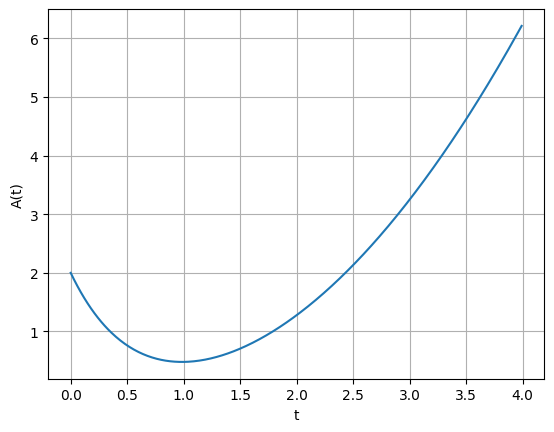

In [5]:
# SEU CÓDIGO DO ITEM 3A

lista_A_euler = [0]*len(lista_t)

lista_A_euler[0] = A_0

i = 0
while(i<len(lista_t)-1):
    lista_A_euler[i+1] = lista_A_euler[i] + ( -2 * lista_A_euler[i] + lista_t[i] ** 2) * dt
    i = i+1

plt.plot(lista_t, lista_A_euler)

plt.xlabel("t")
plt.ylabel("A(t)")
plt.grid(True)
plt.show()

#### c)
Agora, você irá resolver a equação novamente pelo método de Euler, porém **utilizando a função que você implementou no item 2a** para calcular a derivada $\frac{dA}{dt}$. Ou seja, em vez de digitar a expressão da derivada diretamente no loop, você irá chamar a função do item 2a para obter seu valor.
Considere a mesma lista de tempo do item 2 e plote o gráfico de $A(t)$ por $t$.

**Obs.:** dê algum nome para a lista com os valores de $A(t)$ que seja diferente dos utilizados anteriormente.

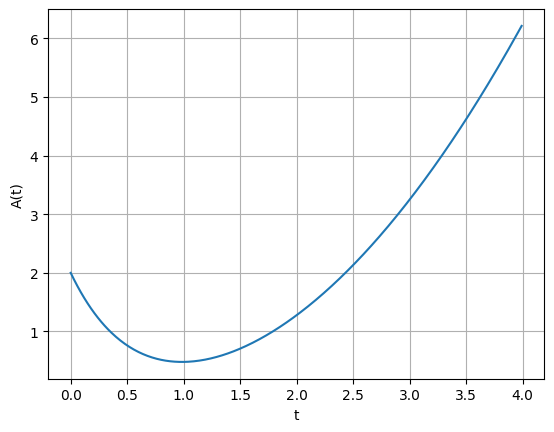

In [6]:
# SEU CÓDIGO DO ITEM 3C

lista_A_euler_2 = [0]*len(lista_t)

lista_A_euler_2[0] = A_0

i = 0
while(i<len(lista_t)-1):
    dAdt = modelo2( lista_A_euler_2[i] , lista_t[i] )
    lista_A_euler_2[i+1] = lista_A_euler_2[i] + dAdt * dt
    i = i+1

plt.plot(lista_t, lista_A_euler_2)


plt.xlabel("t")
plt.ylabel("A(t)")
plt.grid(True)
plt.show()

#### d)
Plote as três soluções (itens 2a, 3b e 3c) em um mesmo gráfico.

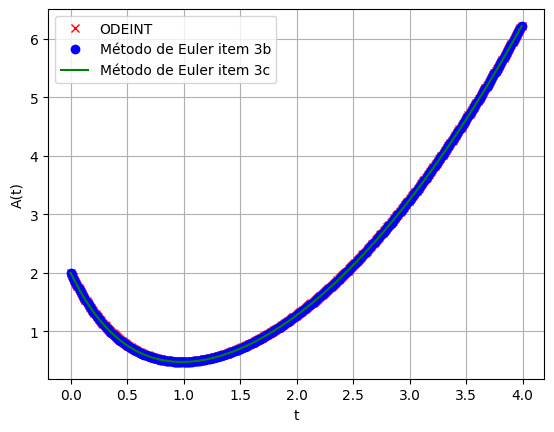

In [7]:
# SEU CÓDIGO DO ITEM 3D

plt.plot(lista_t, lista_A , 'rx', label = "ODEINT" )
plt.plot(lista_t, lista_A_euler , 'bo' , label = "Método de Euler item 3b" )
plt.plot(lista_t, lista_A_euler_2 , 'g-' , label = "Método de Euler item 3c" )

plt.xlabel("t")
plt.ylabel("A(t)")
plt.grid(True)
plt.legend()
plt.show()